# ANÁLISE EXPLORATÓRIA

### IMPORT DAS BIBLIOTECAS E DOS DADOS

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zarr
import gcsfs

print("zarr:", zarr.__version__)
print("xarray:", xr.__version__)

zarr: 3.1.6
xarray: 2025.12.0


In [2]:
url = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

In [3]:
ds = xr.open_zarr(url,storage_options={"token": "anon"},)
ds

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * time                                                             (time) datetime64[ns] 11MB ...
  * latitude                                                         (latitude) float32 3kB ...
  * longitude                                                        (longitude) float32 6kB ...
  * level                                                            (level) int64 296B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 5TB ...
Attributes:
    last_updated:           2026-08-08 03:20:46.413647+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2026-04-30
    valid_time_stop_era5t:  2026-08-02

In [4]:
#print(ds)
#print(ds.dims)
#print(ds.coords)
print(list(ds.data_vars))

['100m_u_component_of_wind', '100m_v_component_of_wind', '10m_u_component_of_neutral_wind', '10m_u_component_of_wind', '10m_v_component_of_neutral_wind', '10m_v_component_of_wind', '10m_wind_gust_since_previous_post_processing', '2m_dewpoint_temperature', '2m_temperature', 'air_density_over_the_oceans', 'angle_of_sub_gridscale_orography', 'anisotropy_of_sub_gridscale_orography', 'benjamin_feir_index', 'boundary_layer_dissipation', 'boundary_layer_height', 'charnock', 'clear_sky_direct_solar_radiation_at_surface', 'cloud_base_height', 'coefficient_of_drag_with_waves', 'convective_available_potential_energy', 'convective_inhibition', 'convective_precipitation', 'convective_rain_rate', 'convective_snowfall', 'convective_snowfall_rate_water_equivalent', 'downward_uv_radiation_at_the_surface', 'duct_base_height', 'eastward_gravity_wave_surface_stress', 'eastward_turbulent_surface_stress', 'evaporation', 'forecast_albedo', 'forecast_logarithm_of_surface_roughness_for_heat', 'forecast_surface

### PRECITAÇÃO

In [5]:
#nomes relacionados a precitação
[var for var in ds.data_vars if "precip" in var.lower()]

['convective_precipitation',
 'instantaneous_large_scale_surface_precipitation_fraction',
 'large_scale_precipitation',
 'large_scale_precipitation_fraction',
 'maximum_total_precipitation_rate_since_previous_post_processing',
 'mean_convective_precipitation_rate',
 'mean_large_scale_precipitation_fraction',
 'mean_large_scale_precipitation_rate',
 'mean_total_precipitation_rate',
 'minimum_total_precipitation_rate_since_previous_post_processing',
 'precipitation_type',
 'total_precipitation']

In [6]:
precip = ds["total_precipitation"]

precip

<xarray.DataArray 'total_precipitation' (time: 1323648, latitude: 721,
                                         longitude: 1440)> Size: 5TB
[1374264299520 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 11MB 1900-01-01 ... 2050-12-31T23:00:00
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes:
    long_name:   Total precipitation
    short_name:  tp
    units:       m

In [7]:
print(precip.dims)
print(precip.attrs)

('time', 'latitude', 'longitude')
{'long_name': 'Total precipitation', 'short_name': 'tp', 'units': 'm'}


In [8]:
def extrair_precipitacao_mensal(
    ds,
    inicio,
    fim,
    lat_norte=15,
    lat_sul=-60,
    lon_oeste=275,
    lon_leste=330,
):
    precip = ds["total_precipitation"].sel(
        time=slice(inicio, fim),
        latitude=slice(lat_norte, lat_sul),
        longitude=slice(lon_oeste, lon_leste),
    )

    precip_mensal_mm = precip.sum(dim="time") * 1000

    #precipitação não pode ser negativa.
    #pequenos valores negativos podem surgir por precisão numérica.
    precip_mensal_mm = precip_mensal_mm.clip(min=0)

    precip_mensal_mm.attrs["units"] = "mm"
    precip_mensal_mm.attrs["long_name"] = "Monthly total precipitation"

    return precip_mensal_mm

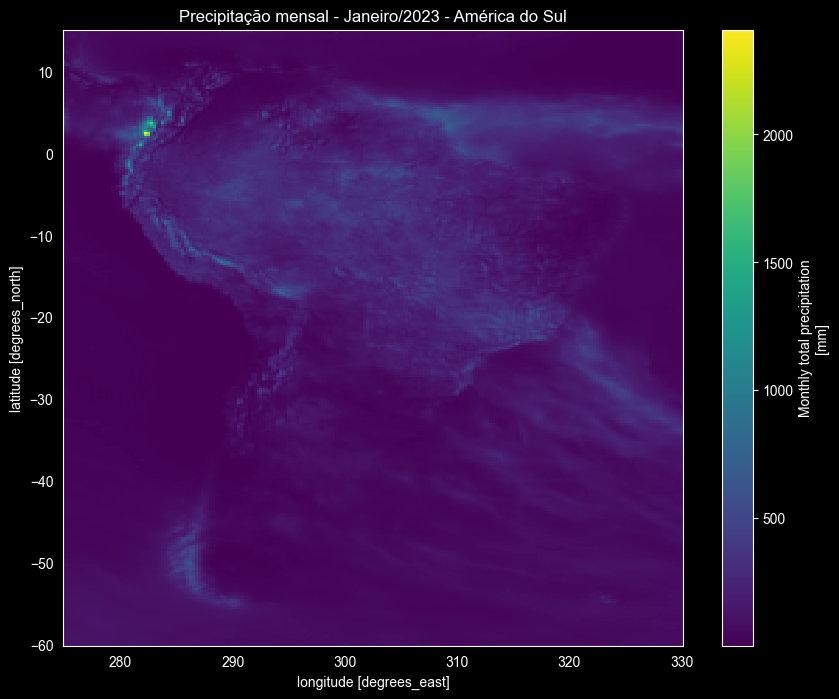

In [9]:
jan_2023 = extrair_precipitacao_mensal(
    ds,
    "2023-01-01",
    "2023-01-31T23:00:00"
)

jan_2023.plot(figsize=(10, 8))
plt.title("Precipitação mensal - Janeiro/2023 - América do Sul")
plt.show()
#salvando as visualizações
jan_2023.to_netcdf("../data/interim/precip_jan_2023_america_sul.nc")

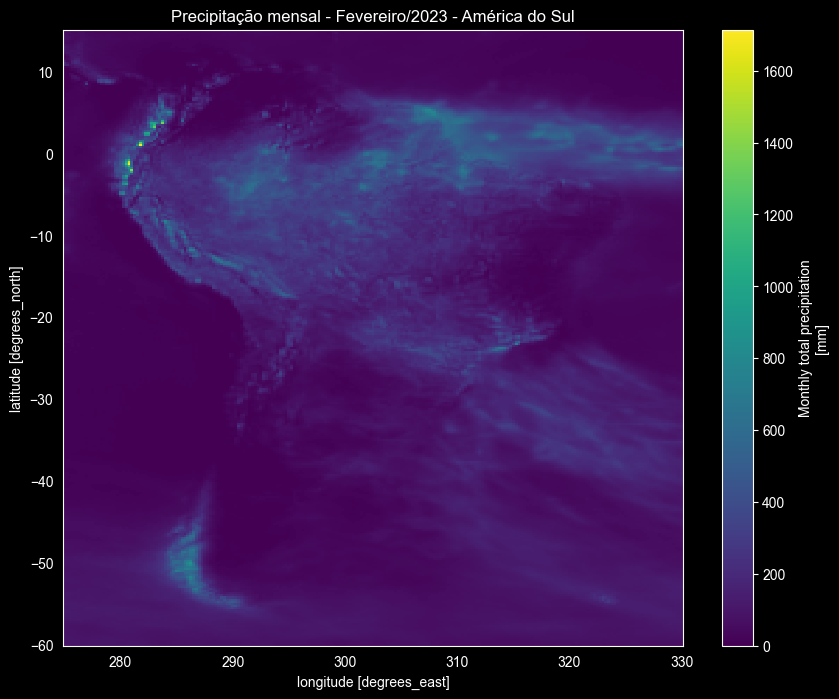

In [10]:
fev_2023 = extrair_precipitacao_mensal(
    ds,
    "2023-02-01",
    "2023-02-28T23:00:00"
)

fev_2023.plot(figsize=(10, 8))
plt.title("Precipitação mensal - Fevereiro/2023 - América do Sul")
plt.show()

fev_2023.to_netcdf("../data/interim/precip_fev_2023_america_sul.nc")

In [11]:
print("Mínimo:", float(fev_2023.min()))
print("Máximo:", float(fev_2023.max()))
print("Média:", float(fev_2023.mean()))

print("Quantidade de valores negativos:", int((fev_2023 < 0).sum()))

Mínimo: 0.0
Máximo: 1714.2459716796875
Média: 113.60517883300781
Quantidade de valores negativos: 0


### TEMPERATURA

In [12]:
#nomes relacionados a temperatura
[var for var in ds.data_vars if "temperature" in var.lower()]

['2m_dewpoint_temperature',
 '2m_temperature',
 'ice_temperature_layer_1',
 'ice_temperature_layer_2',
 'ice_temperature_layer_3',
 'ice_temperature_layer_4',
 'lake_bottom_temperature',
 'lake_ice_temperature',
 'lake_mix_layer_temperature',
 'lake_total_layer_temperature',
 'maximum_2m_temperature_since_previous_post_processing',
 'minimum_2m_temperature_since_previous_post_processing',
 'sea_surface_temperature',
 'skin_temperature',
 'soil_temperature_level_1',
 'soil_temperature_level_2',
 'soil_temperature_level_3',
 'soil_temperature_level_4',
 'temperature',
 'temperature_of_snow_layer',
 'vertical_integral_of_temperature']

### VENTO

In [13]:
#nomes relacionados ao vento
[var for var in ds.data_vars if "wind" in var.lower()]

['100m_u_component_of_wind',
 '100m_v_component_of_wind',
 '10m_u_component_of_neutral_wind',
 '10m_u_component_of_wind',
 '10m_v_component_of_neutral_wind',
 '10m_v_component_of_wind',
 '10m_wind_gust_since_previous_post_processing',
 'instantaneous_10m_wind_gust',
 'mean_direction_of_wind_waves',
 'mean_period_of_wind_waves',
 'mean_wave_period_based_on_first_moment_for_wind_waves',
 'mean_wave_period_based_on_second_moment_for_wind_waves',
 'ocean_surface_stress_equivalent_10m_neutral_wind_direction',
 'ocean_surface_stress_equivalent_10m_neutral_wind_speed',
 'significant_height_of_combined_wind_waves_and_swell',
 'significant_height_of_wind_waves',
 'u_component_of_wind',
 'v_component_of_wind',
 'wave_spectral_directional_width_for_wind_waves']

### LATITUDE E LONGITUDE

In [14]:
print(ds.latitude.min().values)
print(ds.latitude.max().values)

-90.0
90.0


In [15]:
print(ds.longitude.min().values)
print(ds.longitude.max().values)

0.0
359.75


## TEMPO (MIN, MAX)

In [16]:
print(ds.time.min().values)
print(ds.time.max().values)

1900-01-01T00:00:00.000000000
2050-12-31T23:00:00.000000000
